# Introduzione alla classificazione

<img src="https://www.mrtfuelcell.polimi.it/images/logo_poli.jpg" height="200">
<img src="https://upload.wikimedia.org/wikipedia/commons/f/f8/Python_logo_and_wordmark.svg" height="150">

Corso ML A2A - giorno 5 - 31/10/2024

Maciej Sakwa, Micheal Wood, Emanuele Ogliari

## Indice

1. Struttura di un progetto di Machine Learning (ripasso)
2. Regressione Logistica
3. Metriche di valutazione nella classificazione
4. Caso di studio (dati EV + classificazione multiclasse)

## Obiettivi di apprendimento

* Comprendere la funzione logistica e il suo utilizzo nei problemi di classificazione
* Definire le metriche tipiche usate per descrivere i problemi di classificazione (accuratezza, precisione, richiamo)
* Comprendere le differenze di approccio tra problemi binari e a scelta multipla




**Esegui le celle qui sotto con gli import e le dichiarazioni delle funzioni** 

Sentiti libero di saltare i dettagli del contenuto.

---

Import:

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.display.float_format = '{:.2f}'.format # print 2 decimal places
pd.options.mode.chained_assignment = None

Funzioni di preprocessing dei dati:

In [2]:
def import_data(filepath):
    df = pd.read_csv(filepath,index_col='time',)
    df.index = pd.to_datetime(df.index,utc=True,format='ISO8601')
    df.index = df.index.tz_convert('Europe/Madrid').tz_localize(None)
    return df

def preprocess_data(data):

    zeros_list = [
        'generation fossil coal-derived gas',
        'generation fossil oil shale',
        'generation fossil peat',
        'generation geothermal',
        'generation marine',
        'generation wind offshore',
        'generation hydro pumped storage aggregated',
        'forecast wind offshore eday ahead']
    nonzeros_list = [x for x in data.columns if x not in zeros_list]

    generations_list = [x for x in nonzeros_list if x.startswith('generation')]

    data = data[generations_list]

    return data.ffill()

Funzioni matematiche:

In [3]:
def logit(x):
    return 1 / (1 + np.exp(-x))

def log_loss(labels, probas):
    
    log_probas = np.log([probas[i] if labels[i] == 1 else (1-probas[i]) for i in range(len(probas))])
    loss = sum(log_probas)

    return np.mean(-loss)

Funzioni per i grafici:

In [4]:
def plot_scatter(data, x_col='generation fossil hard coal', y_col='generation wind onshore', w=None, b=None, GoF=False):

    groups = data.groupby('label')
    for name, group in groups: 
        plt.scatter(x=group[x_col], y=group[y_col], label=f'Label: {name}')
    plt.xlabel('Generation Coal (GW) - x')
    plt.ylabel('Generation Wind (GW) - y')

    if w is not None:
        x = np.linspace(data[x_col].min(), data[x_col].max(), 100)
        y = w * x + b
        plt.plot(x, y, linestyle='--', c='r', label='Division boundary')

    if GoF:
        est = (data[y_col] - (w * data[x_col] + b)) / data[y_col].std()
        probas = logit(est)
        loss = log_loss(data['label'], probas)
        plt.title(f'Log loss: {loss:.2f}')

    plt.legend()
    plt.show()

def plot_logit(data=None, x_col=None, y_col=None, threshold=None, mark_classes=False, **kwargs): # you don't have to understand this code

    x = np.linspace(-6, 6, 1000)
    colors = ['teal', 'orange']

    plt.figure(**kwargs)
    plt.axhline(0, c='k', linestyle = ':', alpha = 0.5, linewidth=1)
    plt.axhline(1, c='k', linestyle = ':', alpha = 0.5, linewidth=1)
    plt.axvline(0, c='k', linewidth=1, alpha = 0.5)
    plt.plot(x, logit(x), c = 'grey')
    plt.title('Logistic function')
    plt.xlabel('Estimate value')
    plt.ylabel('Logit value')

    if data is not None:
        if mark_classes:
            groups = data.groupby('label')
            for i, group in enumerate(groups):
                name, df = group
                plt.scatter(df[x_col], df[y_col], label = f'Class: {name}', c=colors[i], zorder=3, alpha=0.5)
        else:
            plt.scatter(data[x_col], data[y_col], c='r', zorder=3)

    if threshold is not None:
        data['pred'] = [1 if x >= threshold else 0 for x in data[y_col]]
        groups = data.groupby('pred')
        for i, group in enumerate(groups):
            name, df = group
            plt.scatter(df[x_col], df['pred'], c=colors[i], zorder=3, marker='x', label=f'Pred Class: {name}')
            for i, row in df.iterrows():
                x = row[x_col]
                y_1, y_2 = (row[y_col], row['pred'])
                plt.plot([x, x], [y_1, y_2], c='grey', linewidth=0.5, linestyle='--')
        plt.axhline(threshold, c='red', linestyle='--', linewidth=1, label='Threshold')
        plt.legend()

**Hai eseguito tutte le celle?**

---

## Struttura di un progetto di Machine Learning

Importa i dati - è lo stesso dataset di prima. Ora ci concentreremo un po' di più sulle diverse fonti di generazione.

In [5]:
data = import_data('https://raw.githubusercontent.com/woodjmichael/Basi-Fondamentali-del-Machine-Learning/refs/heads/main/data/energy_supply.csv')
data = preprocess_data(data)
data.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore
time,,,,,,,,,,,,,,
2015-01-01 00:00:00,447.00,329.00,4844.00,4821.00,162.00,863.00,1051.00,1899.00,7096.00,43.00,73.00,49.00,196.00,6378.00
2015-01-01 01:00:00,449.00,328.00,5196.00,4755.00,158.00,920.00,1009.00,1658.00,7096.00,43.00,71.00,50.00,195.00,5890.00
2015-01-01 02:00:00,448.00,323.00,4857.00,4581.00,157.00,1164.00,973.00,1371.00,7099.00,43.00,73.00,50.00,196.00,5461.00
2015-01-01 03:00:00,438.00,254.00,4314.00,4131.00,160.00,1503.00,949.00,779.00,7098.00,43.00,75.00,50.00,191.00,5238.00
2015-01-01 04:00:00,428.00,187.00,4130.00,3840.00,156.00,1826.00,953.00,720.00,7097.00,43.00,74.00,42.00,189.00,4935.00


I nostri dati non hanno un'etichetta categorica. Bariamo un po' e aggiungiamo la nostra etichetta

È basata sulla quota di produzione da rinnovabili in una determinata ora 

1 se la quota è superiore al 50%, 0 se è inferiore al 50%

In [6]:
renewables_list = [
    'generation other renewable',
    'generation solar', 
    'generation hydro water reservoir', 
    'generation hydro run-of-river and poundage', 
    'generation biomass',
    'generation wind onshore',
    'generation hydro pumped storage consumption',
    ]

data['renewables share'] = data[renewables_list].sum(axis=1)  / data.sum(axis=1)
data['label'] = [1 if i >= 0.5 else 0 for i in data['renewables share']]

Traccia l'etichetta e la quota:

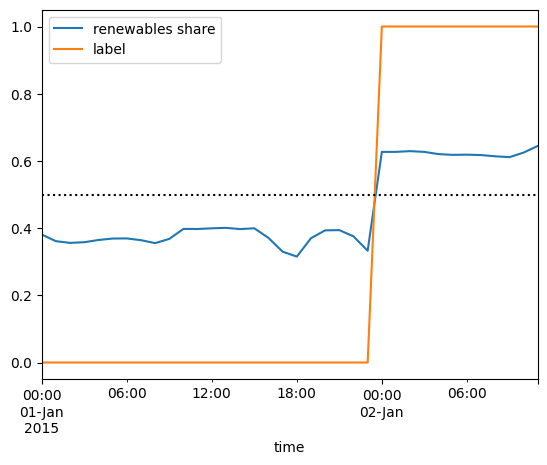

In [7]:
data[['renewables share','label']][:36].plot()
plt.axhline(0.5, c='k', linestyle=':', label='cutoff');

In [8]:
data.label.value_counts()

label
0    27311
1     7753
Name: count, dtype: int64

**DEFINIZIONE DEL PROBLEMA:** Rilevare la classe (maggioranza o minoranza di rinnovabili nella quota) in base alle variabili del dataset. 

|I/O|  Dati |
| --- | --- |
|Input| `generation fossil coal hard`, `generation wind onshore`, ecc. |
|Target|  `label` |
|Output| `label estimate` |

Proviamo ad affrontare l'argomento come abbiamo fatto prima:

Importa le librerie:

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler 

Dividi input ed etichette:

In [10]:
input_columns = data.columns.to_list() 
input_columns.remove('label')

inputs = data[input_columns].copy()
labels = data[['label']].copy()

Scala gli input:

In [11]:
scaler = MinMaxScaler() 

inputs_scaled = scaler.fit_transform(inputs) 
labels_scaled = labels.values.ravel()

Dividi in dataset di addestramento e di test:

In [12]:
n = len(inputs) 
cutoff = int(0.7*n) # Train on 70% of the data, test on 30%

train_inputs = inputs_scaled[:cutoff]   # Cut before
train_labels = labels_scaled[:cutoff]   # Cut before

test_inputs = inputs_scaled[cutoff:]    # Cut after
test_labels = labels_scaled[cutoff:]    # Cut after

Dichiara e adatta il modello lineare:

In [13]:
model = LinearRegression()
model.fit(X=train_inputs, y=train_labels)

LinearRegression()

Mostra i risultati:

In [14]:
results = model.predict(test_inputs)

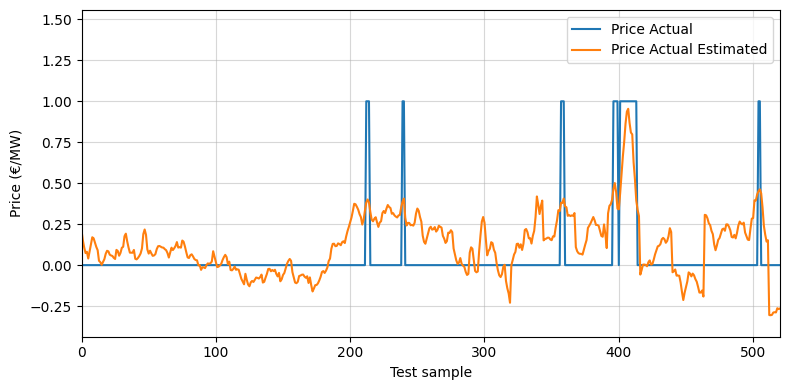

In [15]:
plt.figure(figsize=(8, 4))

# Plots
plt.plot(test_labels, label='Price Actual')
plt.plot(results, label='Price Actual Estimated')

# Visuals
plt.xlim((0,520))
plt.xlabel('Test sample')
plt.ylabel('Price (€/MW)')
plt.grid(which='major', alpha = 0.5)

# Tidy up
plt.legend()
plt.tight_layout()
plt.show()

È spazzatura!  

In questo caso salteremo la valutazione dei risultati, dato che è ovvio che non andremo bene.

Inoltre, per la classificazione dovremo definire nuove metriche più adatte al compito.

## Regressione logistica

Dato che non stiamo prevedendo un valore esatto, una tradizionale regressione lineare è inutile.

Dobbiamo creare una funzione che restituisca valori tra 0 e 1.

### Regressione logistica - "a mano" 

Nella regressione lineare standard il nostro output era definito con un'equazione $ w \cdot X + b = \hat{y} $.

Consideriamo per ora un caso 2D con 2 colonne di dati:

In [16]:
X = data[['generation fossil hard coal', 'generation wind onshore', 'label']][0:120]

Possiamo visualizzarlo in un grafico a dispersione:

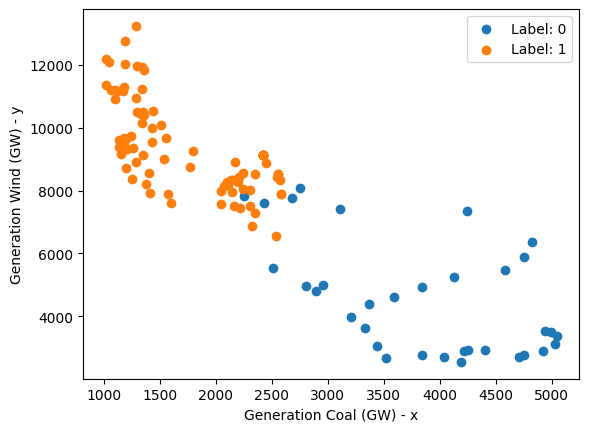

In [17]:
plot_scatter(X)

Le istanze sono colorate in base all'etichetta che abbiamo definito prima, arancione significa quota di rinnovabili alta, blu il contrario.

La cosa interessante è che possiamo facilmente *vedere* la divisione tra i gruppi.

Infatti, proviamo a tracciare una linea tra i gruppi:

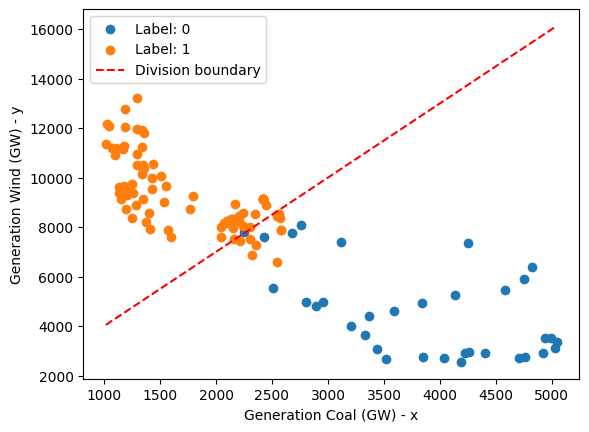

In [18]:
w = 3
b = 1000

plot_scatter(X, w=w, b=b)

Possiamo "stimare" la classe decidendo se il punto è sopra o sotto la nostra linea. Se è sopra è positivo, altrimenti negativo.

Possiamo farlo semplicemente sottraendo il valore y della linea dal valore y del punto.

In [19]:
X['estimate'] = (X['generation wind onshore'] - (w * X['generation fossil hard coal'] + b))     # Subtract the line value
X['estimate'] = X['estimate'] / (X['generation wind onshore'].std())                            # Standardize by dividing by the standard deviation of y (just for better scale)
X.head()

,generation fossil hard coal,generation wind onshore,label,estimate
time,,,,
2015-01-01 00:00:00,4821.00,6378.00,0,-3.42
2015-01-01 01:00:00,4755.00,5890.00,0,-3.53
2015-01-01 02:00:00,4581.00,5461.00,0,-3.49
2015-01-01 03:00:00,4131.00,5238.00,0,-3.07
2015-01-01 04:00:00,3840.00,4935.00,0,-2.85


Ci siamo ritrovati con una serie di valori positivi e negativi specificati per i punti nel nostro dataset. Dobbiamo convertirli in qualche modo in classi.

Quindi ciò che dobbiamo davvero fare è imporre una funzione $\sigma$ sui nostri risultati, che li appiattisca alle estremità a 0 e 1.

$$ \sigma(\hat{y}) = \sigma(w \cdot X + b) $$

dove $\sigma$ è la nostra funzione di appiattimento.

La risposta è la **funzione logistica** (chiamata anche unità **log**istica, o **logit** in breve):

$$
\sigma(\hat{y}) = \frac{1}{1 - \exp(-(w \cdot X + b))}
$$

Per tracciare la funzione logit esegui le celle qui sotto:

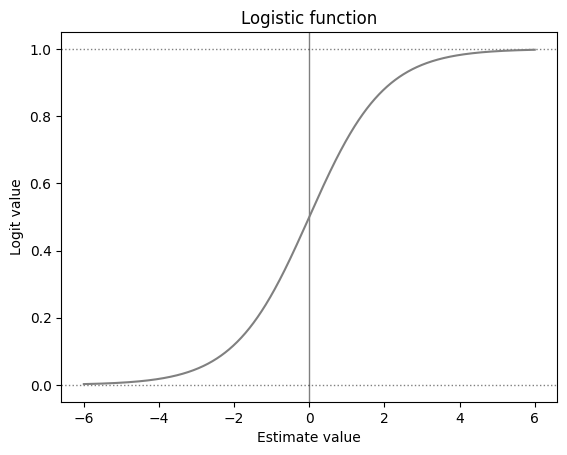

In [20]:
plot_logit()

Potresti ricordarla dalla lezione precedente :) 

Applichiamola alla nostra stima:

In [21]:
X['logit estimate'] = logit(X['estimate'])
X.head()

,generation fossil hard coal,generation wind onshore,label,estimate,logit estimate
time,,,,,
2015-01-01 00:00:00,4821.00,6378.00,0,-3.42,0.03
2015-01-01 01:00:00,4755.00,5890.00,0,-3.53,0.03
2015-01-01 02:00:00,4581.00,5461.00,0,-3.49,0.03
2015-01-01 03:00:00,4131.00,5238.00,0,-3.07,0.04
2015-01-01 04:00:00,3840.00,4935.00,0,-2.85,0.05


Tracciamo i punti:

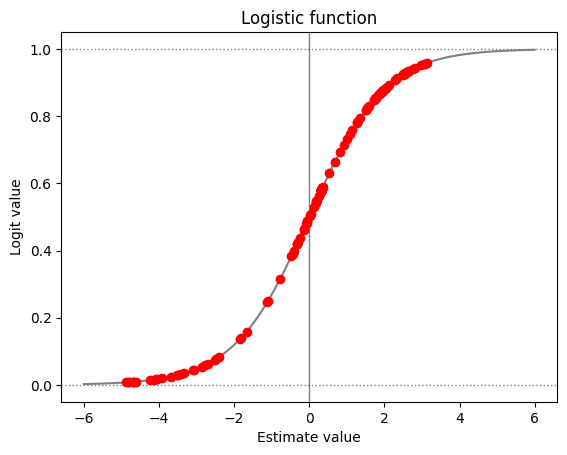

In [22]:
plot_logit(X, x_col='estimate', y_col='logit estimate') # Put mark_classes = True to see the true class of each point

L'output della funzione logistica non è davvero l'etichetta binaria 0-1. È un valore nell'intervallo 0-1.

Diciamo che l'output di una funzione logistica è la **probabilità** stimata che un input appartenga alla classe 1.

$
    \hat{p} = \sigma(\hat{y}) 
$

In [23]:
X.head()

,generation fossil hard coal,generation wind onshore,label,estimate,logit estimate
time,,,,,
2015-01-01 00:00:00,4821.00,6378.00,0,-3.42,0.03
2015-01-01 01:00:00,4755.00,5890.00,0,-3.53,0.03
2015-01-01 02:00:00,4581.00,5461.00,0,-3.49,0.03
2015-01-01 03:00:00,4131.00,5238.00,0,-3.07,0.04
2015-01-01 04:00:00,3840.00,4935.00,0,-2.85,0.05


Per esempio, il primo punto alle 2015-01-01 00:00:00 ha una **probabilità del 3%** di appartenere alla **classe 1**.

Quindi probabilmente non è un membro della **classe 1**. Ma se fosse **60%**? Appartiene alla **classe 1** oppure no?

Qual è la percentuale di soglia?

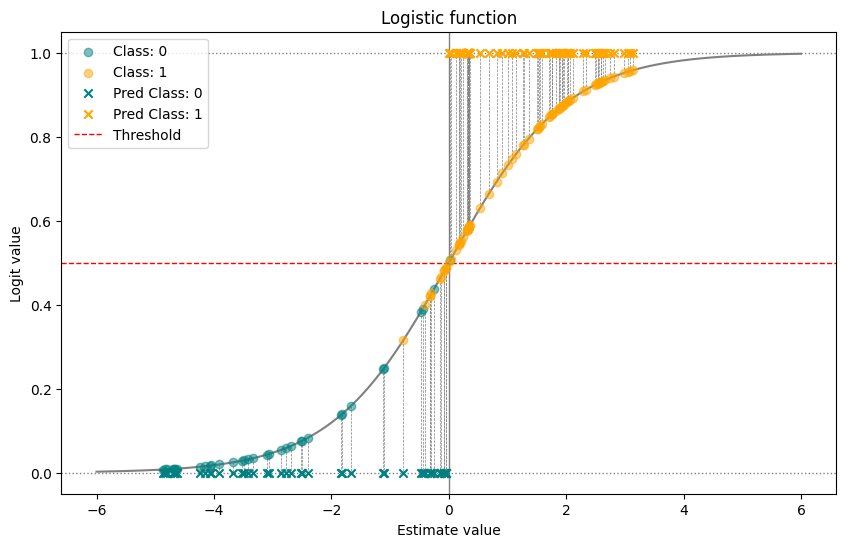

In [24]:
selected_threshold = 0.5  # Try to change the threshold a bit to see how it changes

# PLot the logit
plot_logit(X, x_col='estimate', y_col='logit estimate', mark_classes=True, threshold=selected_threshold, figsize=(10, 6))

In [25]:
X['pred'] = [1 if est >= selected_threshold else 0 for est in X['logit estimate']]
X.head()

,generation fossil hard coal,generation wind onshore,label,estimate,logit estimate,pred
time,,,,,,
2015-01-01 00:00:00,4821.00,6378.00,0,-3.42,0.03,0
2015-01-01 01:00:00,4755.00,5890.00,0,-3.53,0.03,0
2015-01-01 02:00:00,4581.00,5461.00,0,-3.49,0.03,0
2015-01-01 03:00:00,4131.00,5238.00,0,-3.07,0.04,0
2015-01-01 04:00:00,3840.00,4935.00,0,-2.85,0.05,0


**Ed eccoci qui!** Le istanze sono divise in classi binarie separate. 

### Bontà di adattamento

Ora dobbiamo specificare la metrica di *bontà di adattamento* che l'algoritmo deve minimizzare (in modo simile ai quadrati nella regressione). Nel caso della classificazione si chiama **Log-Loss** o **Cross-Entropy**:

$
    L_{log}(y, p) = -(y_1 \log(p_1) + (1-y_0) \log(1-p_0)) 
$

In [26]:
log_loss(probas=X['logit estimate'], labels=X['label'])  # It's the original label, not the prediction!

35.23926783577385

Riesci a regolare i parametri *w* e *b* per minimizzare la perdita?

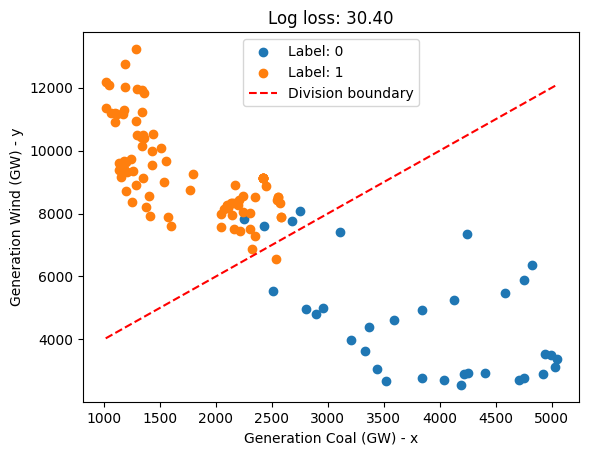

In [27]:
w = 2
b = 2000

plot_scatter(X, w=w, b=b, GoF=True)

Per qualsiasi nuovo dato in ingresso (ad es. i dati di test), possiamo semplicemente calcolare la funzione adattata e il suo logit per stimare la classe.

## Metriche di valutazione nella classificazione

Come vedi, con la classificazione abbiamo a che fare con **categorie** e **probabilità** invece che con valori reali

Quindi non possiamo usare le stesse metriche per valutare il nostro modello

*niente MAE, niente MSE, niente RMSE, niente MAPE*

Invece, basiamo la nostra valutazione su una **MATRICE DI CONFUSIONE**

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

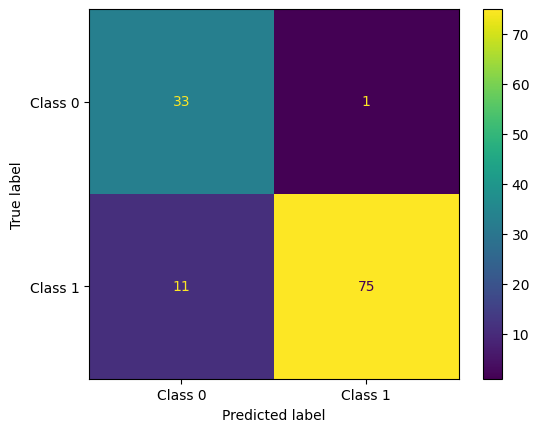

In [29]:
cm = confusion_matrix(X['label'], X['pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot()
plt.show()

**Accuratezza** - percentuale di classi identificate correttamente:

In [30]:
a = (33 + 75) / (33 + 1 + 11 + 75)

print(f'Global accuracy: {a:.2f}')

Global accuracy: 0.90


**Precisione** - la pulizia delle classi previste:

In [31]:
p_0 = 33 / (11 + 33)
p_1 = 75 / (1 + 75)

print(f'Precision: \n -Class 0: {p_0:.2f}\n -Class 1: {p_1:.2f}')

Precision: 
 -Class 0: 0.75
 -Class 1: 0.99


**Richiamo (Recall)** - il tasso di cattura della classe vera:

In [32]:
r_0 = 33 / (33 + 1)
r_1 = 75 / (11 + 75)

print(f'Recall: \n -Class 0: {r_0:.2f}\n -Class 1: {r_1:.2f}')

Recall: 
 -Class 0: 0.97
 -Class 1: 0.87


**F1-score** - combina precisione e richiamo. Favorisce valori simili tra i due (non sempre un bene)

In [33]:
f1_0 = 2 * p_0 * r_0 / (p_0 + r_0)
f1_1 = 2 * p_1 * r_1 / (p_1 + r_1)

print(f'F1: \n -Class 0: {f1_0:.2f}\n -Class 1: {f1_1:.2f}')

F1: 
 -Class 0: 0.85
 -Class 1: 0.93


### Compromesso tra precisione e richiamo

I valori di precisione e richiamo dipendono dal nostro modello e dalla soglia selezionata.

Purtroppo non possiamo aumentare **precisione** e **richiamo** allo stesso tempo. 

Più aumentiamo la pulizia del nostro gruppo (la precisione cresce), più il tasso di cattura (richiamo) diminuisce. 

Possiamo visualizzarlo facilmente nel grafico logit:

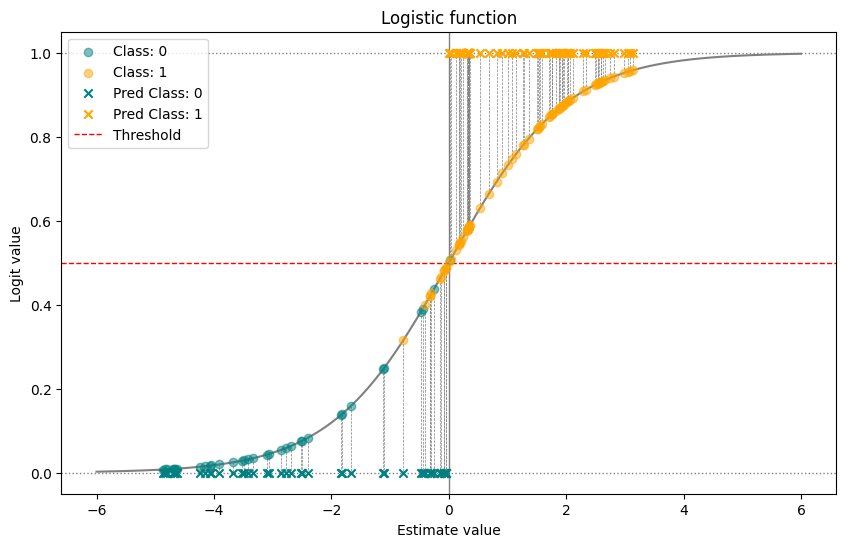

In [34]:
selected_threshold = 0.50

# PLot the logit
plot_logit(X, x_col='estimate', y_col='logit estimate', mark_classes=True, threshold=selected_threshold, figsize=(10, 6))

#plt.xlim(-0.7, 0.7)

In effetti possiamo calcolare precisione e richiamo per molte soglie diverse, e tracciare la relazione:

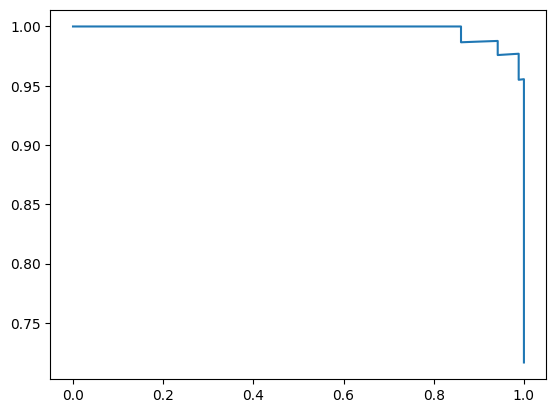

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(X['label'], X['logit estimate'])

plt.plot(recall, precision)
plt.show()

Il grafico mostra il compromesso tra precisione e richiamo a varie soglie ed è spesso chiamato **curva precisione-richiamo**

Viene spesso usato per confrontare le prestazioni dei classificatori sullo stesso dataset.

Per **un classificatore perfetto** la curva è quasi un quadrato (come nel nostro semplicissimo esempio).

## Caso di studio

### 1. Definizione del problema

<img src="https://www.mrtfuelcell.polimi.it/images/logo_poli.jpg" height="200">
<img src="https://logowik.com/content/uploads/images/technischen-universitat-berlin1469.jpg" height="200">


Il dataset che useremo proviene da una registrazione dettagliata di batterie LG agli ioni di litio effettuata congiuntamente da PoliMi e TUB. È composto da dati di scarica di più celle di batteria a diversi cicli di guida (LA92, US06, ecc.) e a varie temperature comprese tra -25 e +35.

Il dataset è stato pubblicato ad accesso libero ed è accessibile [qui](https://data.mendeley.com/datasets/6hyhsjbwkb/1)

In questo caso di studio useremo un piccolo estratto del dataset completo.

**COMPITO: Stimare lo stato di carica della batteria (State-of-Charge, alto, medio, basso) in base a parametri semplici (I, V, T)**

|I/O|  Dati |
| --- | --- |
|Input| `I`, `V`, `T` |
|Target|  `label` (Alto, Medio, Basso)|
|Output| `label estimate` (Alto, Medio, Basso)|

Nel nostro dataset abbiamo il valore effettivo dello SoC, tuttavia per un semplice problema di classificazione lo convertiremo in 3 classi - carica Alta - Media - Bassa (per suddivisioni al 100% - 75% - 25% - 0% rispettivamente).

<img src='https://raw.githubusercontent.com/woodjmichael/Basi-Fondamentali-del-Machine-Learning/refs/heads/main/images/battery_class.png' width=400>

### 2. Introduzione e analisi dei dati

Carichiamo i nostri dati e osserviamoli:

In [36]:
data_bat = pd.read_csv('https://raw.githubusercontent.com/woodjmichael/Basi-Fondamentali-del-Machine-Learning/refs/heads/main/data/battery_data.csv') # Replace url
data_bat

,V,I,T,Q,SoC
0,1.00,0.86,0.00,0.00,1.00
1,0.98,0.83,0.00,0.00,1.00
2,0.96,0.80,0.00,0.00,1.00
3,0.96,0.82,0.01,0.00,0.99
4,0.93,0.77,0.03,0.00,0.99
...,...,...,...,...,...
2210,0.28,0.31,0.85,0.89,0.06
2211,0.23,0.31,0.89,0.93,0.05
2212,0.22,0.40,0.91,0.91,0.03
2213,0.15,0.19,0.93,1.00,0.02


Sono già stati pre-elaborati quindi non dobbiamo preoccuparci di pulizia o scaling. 

Tutte le feature vanno da 0 a 1.

Diamo un'occhiata ai cicli di guida:

In [37]:
px.line(data_frame=data_bat, y='SoC', width=1000, height=600) 

Aggiungiamo la colonna dell'etichetta in base al valore di SoC:

In [38]:
data_bat['label'] = ['high' if soc > 0.75 else 'low' if soc < 0.25 else 'medium' for soc in data_bat['SoC']]

Verifichiamo i cicli di guida:

In [39]:
px.scatter(data_frame=data_bat, y='SoC', color='label', width=1000, height=600) # Replace 'SoC' with 'V', 'T', or 'I' to see other features

Tracciamolo in 2D in un grafico a dispersione:

In [40]:
px.scatter(data_frame=data_bat, x='T', y='SoC', color='label', width=1000, height=600)

Possiamo tracciarlo anche in 3D:

In [41]:
fig = px.scatter_3d(data_frame=data_bat, x='V', y='I', z='T', color='label', width=1000, height=600)
fig.update_layout(margin=dict(l=20, r=20, t=20, b=20),)
fig.show()

E controlliamo la tabella finale:

In [42]:
data_bat

,V,I,T,Q,SoC,label
0,1.00,0.86,0.00,0.00,1.00,high
1,0.98,0.83,0.00,0.00,1.00,high
2,0.96,0.80,0.00,0.00,1.00,high
3,0.96,0.82,0.01,0.00,0.99,high
4,0.93,0.77,0.03,0.00,0.99,high
...,...,...,...,...,...,...
2210,0.28,0.31,0.85,0.89,0.06,low
2211,0.23,0.31,0.89,0.93,0.05,low
2212,0.22,0.40,0.91,0.91,0.03,low
2213,0.15,0.19,0.93,1.00,0.02,low


### 3. Costruzione e addestramento del modello

C'è una differenza significativa tra il nostro precedente caso di studio e quello nuovo: **abbiamo 1 classe in più**

Il problema passa da classificazione binaria a classificazione multiclasse

Tuttavia il nostro **modello logistico** supporta solo due classi: 0 e 1

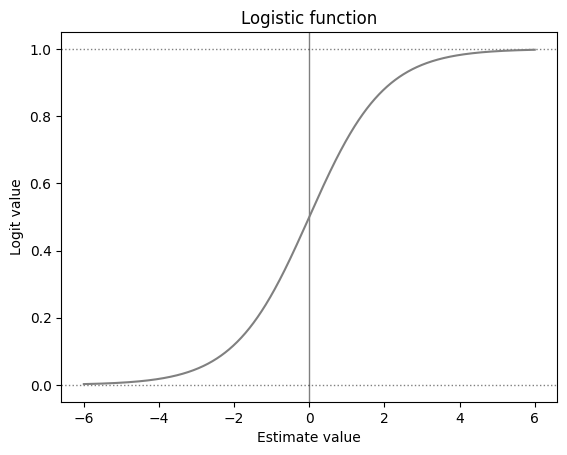

In [43]:
plot_logit()

Come passiamo al caso multiclasse?

**Classificatori ONE vs ALL (uno contro tutti)**

La prima risposta è semplice: addestriamo più classificatori uno-contro-gli-altri, ognuno in grado di prevedere una singola classe.

Aggreghiamo poi i risultati:


<img src='https://amueller.github.io/aml/_images/ovr_lines.png' width=600>

Classificazione multiclasse

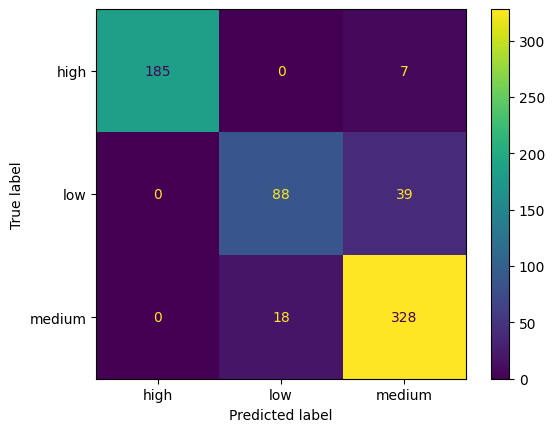

Logistic regression features: 3
Logistic regression iterations: [17 14  6]
---
Class population: 
0
2    346
0    192
1    127
Name: count, dtype: int64
---
Global accuracy: 0.90
---
Classes: ['high' 'low' 'medium']
Precision: [1.         0.83018868 0.87700535]
Recall: [0.96354167 0.69291339 0.94797688]
F1 score: [0.98143236 0.75536481 0.91111111]


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Extract data
X = data_bat[['I', 'V', 'T']].copy()
y = data_bat['label'].copy()

# Encode our labels as 0, 1, 2 instead of text
enc = LabelEncoder()
y = enc.fit_transform(y)

# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Declare the model
logr = LogisticRegression(multi_class='ovr') # OvR training
logr.fit(X_train, y_train)

# Run predictions
y_probas = logr.predict_proba(X_test)
y_preds = np.argmax(y_probas, axis=1)

# Plot confusion matrix
cm = confusion_matrix(y_pred=y_preds, y_true=y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=enc.classes_)
disp.plot()
plt.show()

# Model details
print(f'Logistic regression features: {logr.n_features_in_}')
print(f'Logistic regression iterations: {logr.n_iter_}')

# Display results
df_y = pd.DataFrame(data=y_test)
print(f'---\nClass population: \n{df_y.value_counts()}')
print(f'---\nGlobal accuracy: {accuracy_score(y_test, y_preds):.2f}')
print(f'---\nClasses: {enc.classes_}')
print(f'Precision: {precision_score(y_test, y_preds, average=None)}')
print(f'Recall: {recall_score(y_test, y_preds, average=None)}')
print(f'F1 score: {f1_score(y_test, y_preds, average=None)}')


Funziona bene, ma solo perché il nostro modello è piccolo.

E se il modello fosse enorme e non potessimo permetterci di addestrarlo più volte?

**Funzione SOFTMAX**

La funzione softmax, o Regressione Logistica Multinomiale, è una soluzione comune per modelli di classificazione robusti (ad es. grandi classificatori di immagini) quando non possiamo permetterci di addestrare il modello più volte per le previsioni **OvR**.

<img src='https://images.contentstack.io/v3/assets/bltac01ee6daa3a1e14/blte5e1674e3883fab3/65ef8ba4039fdd4df8335b7c/img_blog_image1_inline_(2).png?width=2048&disable=upscale&auto=webp' width=400>

Fortunatamente, la classe LogisticRegression() di sklearn supporta la funzione softmax. Dobbiamo solo cambiare una riga:

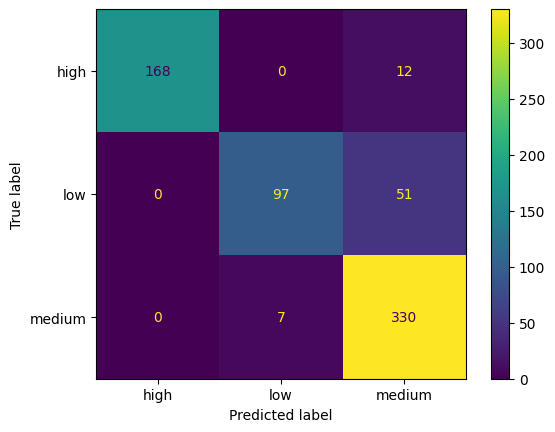

Logistic regression features: 3
Logistic regression iterations: [24]
---
Class population: 
0
2    337
0    180
1    148
Name: count, dtype: int64
---
Global accuracy: 0.89
---
Classes: ['high' 'low' 'medium']
Precision: [1.         0.93269231 0.83969466]
Recall: [0.93333333 0.65540541 0.97922849]
F1 score: [0.96551724 0.76984127 0.90410959]


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Extract data
X = data_bat[['I', 'V', 'T']].copy()
y = data_bat['label'].copy()

# Encode our labels as 0, 1, 2 instead of text
enc = LabelEncoder()
y = enc.fit_transform(y)

# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Declare the model
logr = LogisticRegression(multi_class='multinomial') # we change to 'multinomial'
logr.fit(X_train, y_train)

# Run predictions
y_probas = logr.predict_proba(X_test)
y_preds = np.argmax(y_probas, axis=1)

# Plot confusion matrix
cm = confusion_matrix(y_pred=y_preds, y_true=y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=enc.classes_)
disp.plot()
plt.show()

# Model details
print(f'Logistic regression features: {logr.n_features_in_}')
print(f'Logistic regression iterations: {logr.n_iter_}')

# Display results
df_y = pd.DataFrame(data=y_test)
print(f'---\nClass population: \n{df_y.value_counts()}')
print(f'---\nGlobal accuracy: {accuracy_score(y_test, y_preds):.2f}')
print(f'---\nClasses: {enc.classes_}')
print(f'Precision: {precision_score(y_test, y_preds, average=None)}')
print(f'Recall: {recall_score(y_test, y_preds, average=None)}')
print(f'F1 score: {f1_score(y_test, y_preds, average=None)}')


I dettagli implementativi non sono così importanti. Ricorda solo:

$$
    \text{softmax} = \text{classificazione\ multiclasse}
$$

In effetti, tipicamente per addestrare un classificatore a rete neurale per classi multiple, usiamo anche la funzione softmax per determinare la classe di output:

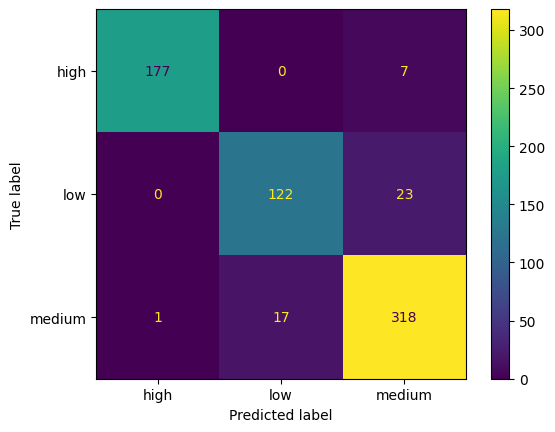

---
Class population: 
0
2    336
0    184
1    145
Name: count, dtype: int64
---
Global accuracy: 0.93
---
Classes: ['high' 'low' 'medium']
Precision: [0.99438202 0.87769784 0.9137931 ]
Recall: [0.96195652 0.84137931 0.94642857]
F1 score: [0.97790055 0.85915493 0.92982456]


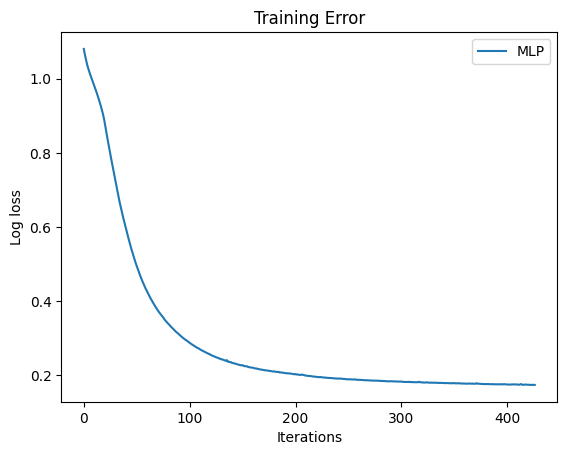

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Extract data
X = data_bat[['I', 'V', 'T']].copy()
y = data_bat['label'].copy()

# Encode our labels as 0, 1, 2 instead of text
enc = LabelEncoder()
y = enc.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Declare the model
mlp = MLPClassifier(hidden_layer_sizes=(10, 10), solver='adam', max_iter=1000)
mlp.fit(X_train, y_train)

# Run predictions
y_probas = mlp.predict_proba(X_test)
y_preds = np.argmax(y_probas, axis=1)

# Plot confusion matrix
cm = confusion_matrix(y_pred=y_preds, y_true=y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=enc.classes_)
disp.plot()
plt.show()

# Training curve
pd.DataFrame({'MLP':mlp.loss_curve_}).plot(title='Training Error',ylabel='Log loss',xlabel='Iterations');

# Display results
df_y = pd.DataFrame(data=y_test)
print(f'---\nClass population: \n{df_y.value_counts()}')
print(f'---\nGlobal accuracy: {accuracy_score(y_test, y_preds):.2f}')
print(f'---\nClasses: {enc.classes_}')
print(f'Precision: {precision_score(y_test, y_preds, average=None)}')
print(f'Recall: {recall_score(y_test, y_preds, average=None)}')
print(f'F1 score: {f1_score(y_test, y_preds, average=None)}')

### 4. Suddivisione avanzata e Cross-Validation (opzionale)

Nonostante i risultati piuttosto buoni dei nostri classificatori, il nostro approccio non è del tutto corretto. 

Questo perché le nostre classi non sono davvero bilanciate - il numero di elementi non è uguale:

In [47]:
data_bat.label.value_counts()

label
medium    1116
high       601
low        498
Name: count, dtype: int64

Infatti, questo si riflette nei risultati, dato che con la nostra suddivisione casuale dei dati non sono coerenti.

Prova a eseguire questa cella alcune volte e osserva come cambiano i risultati:

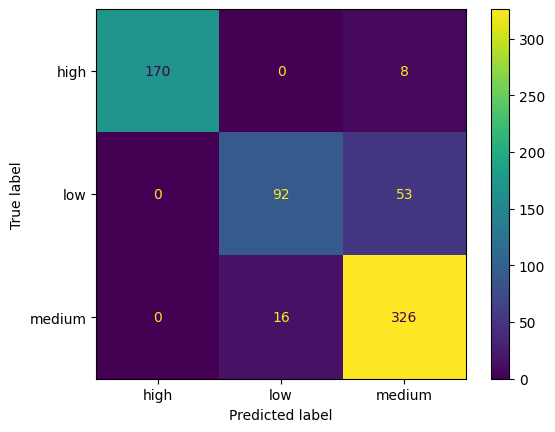

Logistic regression features: 3
Logistic regression iterations: [17 16  7]
---
Class population: 
0
2    342
0    178
1    145
Name: count, dtype: int64
---
Global accuracy: 0.88
---
Classes: ['high' 'low' 'medium']
Precision: [1.         0.85185185 0.84237726]
Recall: [0.95505618 0.63448276 0.95321637]
F1 score: [0.97701149 0.72727273 0.89437586]


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Extract data
X = data_bat[['I', 'V', 'T']].copy()
y = data_bat['label'].copy()

# Encode our labels as 0, 1, 2 instead of text
enc = LabelEncoder()
y = enc.fit_transform(y)

# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Declare the model
logr = LogisticRegression(multi_class='ovr') # OvR training
logr.fit(X_train, y_train)

# Run predictions
y_probas = logr.predict_proba(X_test)
y_preds = np.argmax(y_probas, axis=1)

# Plot confusion matrix
cm = confusion_matrix(y_pred=y_preds, y_true=y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=enc.classes_)
disp.plot()
plt.show()

# Model details
print(f'Logistic regression features: {logr.n_features_in_}')
print(f'Logistic regression iterations: {logr.n_iter_}')

# Display results
df_y = pd.DataFrame(data=y_test)
print(f'---\nClass population: \n{df_y.value_counts()}')
print(f'---\nGlobal accuracy: {accuracy_score(y_test, y_preds):.2f}')
print(f'---\nClasses: {enc.classes_}')
print(f'Precision: {precision_score(y_test, y_preds, average=None)}')
print(f'Recall: {recall_score(y_test, y_preds, average=None)}')
print(f'F1 score: {f1_score(y_test, y_preds, average=None)}')

Le accuratezze saltano su e giù, le popolazioni delle classi saltano su e giù. I risultati non sono coerenti.

Una buona soluzione a questo problema è la **Cross Validation**.

Dividiamo il nostro dataset in K sottogruppi uguali $(x_1, x_2, ..., x_K)$. Addestriamo il modello usando tutti gli altri dati $(1- x_1, 1- x_2, ..., 1- x_K)$
e lo valutiamo sul sottogruppo $(x_1, x_2, ..., x_K)$. Questo approccio è noto come **K-fold Cross Validation**

<img src='https://amueller.github.io/aml/_images/kfold_cv.png' width=600>

Un approccio ancora migliore nel nostro caso sarebbe suddividere i dati in base alla popolazione delle classi. Infatti, possiamo farlo facilmente usando una **K-fold Cross Validation *Stratificata***

<img src='https://amueller.github.io/aml/_images/stratified_cv.png' width=600>

Naturalmente questo approccio è computazionalmente costoso (dobbiamo addestrare K modelli) quindi va bene solo per modelli piccoli.

Addestriamo la nostra Regressione Logistica con K-fold CV:

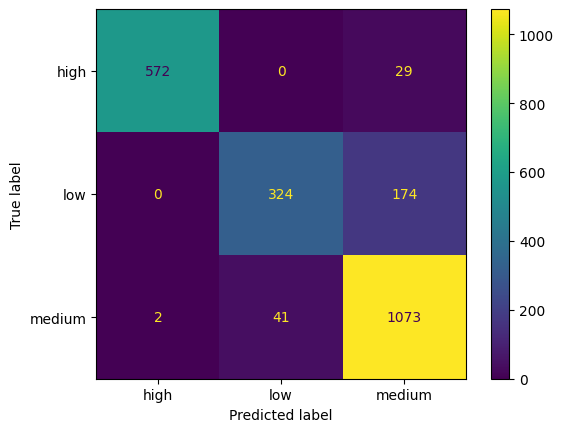

---
Class population: 
0
2    1116
0     601
1     498
Name: count, dtype: int64
---
Global accuracy: 0.89
---
Classes: ['high' 'low' 'medium']
Precision: [0.99651568 0.88767123 0.84090909]
Recall: [0.95174709 0.65060241 0.96146953]
F1 score: [0.97361702 0.75086906 0.89715719]


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Extract data
X = data_bat[['I', 'V', 'T']].copy()
y = data_bat['label'].copy()

# Encode our labels as 0, 1, 2 instead of text
enc = LabelEncoder()
y = enc.fit_transform(y)

# Data split
skf = StratifiedKFold(n_splits=5, shuffle=True) # We use Stratiifed K Fold instead of random train test split

# Declare the model
logr = LogisticRegression(multi_class='ovr') # OvR training

# Run predictions
y_preds = cross_val_predict(logr, X, y, cv=skf) # We put entire X and y, the splitter will take care of splits for us

# Plot confusion matrix
cm = confusion_matrix(y_pred=y_preds, y_true=y)
disp = ConfusionMatrixDisplay(cm, display_labels=enc.classes_)
disp.plot()
plt.show()

# Display results
df_y = pd.DataFrame(data=y)
print(f'---\nClass population: \n{df_y.value_counts()}')
print(f'---\nGlobal accuracy: {accuracy_score(y, y_preds):.2f}')
print(f'---\nClasses: {enc.classes_}')
print(f'Precision: {precision_score(y, y_preds, average=None)}')
print(f'Recall: {recall_score(y, y_preds, average=None)}')
print(f'F1 score: {f1_score(y, y_preds, average=None)}')

Riesegui questa cella alcune volte e osserva i risultati

L'accuratezza è ora molto più stabile, e probabilmente ci dà un'idea migliore delle prestazioni con dati mai visti

### 5. Classificazione con Albero Decisionale e Random Forest (opzionale)

Gli **Alberi Decisionali** (e le **Random Forest**) sono un insieme di modelli molto utili ed estremamente interpretabili, che eccellono nella gestione di dati tabulari.

Tuttavia, per gli alberi decisionali è più facile addestrarli prima e spiegarli dopo:

In [50]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


# Extract data
X = data_bat[['V', 'T', 'I']].copy()
y = data_bat['label'].copy()

# Encode our labels as 0, 1, 2 instead of text
enc = LabelEncoder()
y = enc.fit_transform(y)

# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Declare the model
dt = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=0)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=0)

Come suggerisce il nome, il modello fa crescere un albero di decisioni binarie. Partendo dal nodo radice, divide i campioni in due gruppi. 

A ogni nodo cerca una condizione di suddivisione che minimizzi l'**impurità** (ufficialmente la metrica si chiama **gini impurity**), che è pari a 1 meno la somma delle probabilità al quadrato di ogni classe:

$$
    G_i = 1 - \sum^n_{k=1} p_{i, k}^2
$$

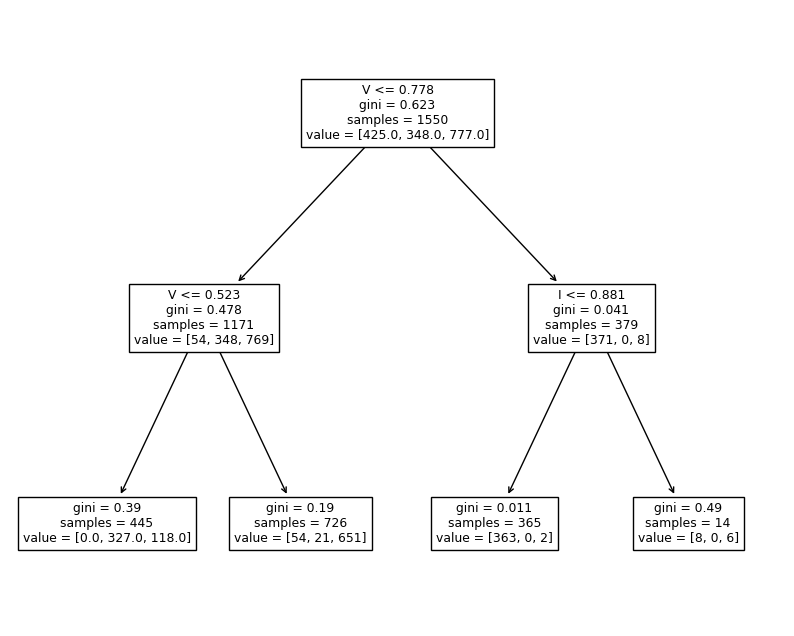

In [51]:
plt.figure(figsize=(10, 8))
plot_tree(dt, feature_names=dt.feature_names_in_)
plt.show()

Il problema più grande del **DecisionTreeClassifier** è che tende a fare un overfitting severo dei dati.

Infatti, se non fermato in tempo continuerà a dividere finché ogni campione non sarà in una foglia separata. Per contrastare questo possiamo:
* Tagliare le suddivisioni non necessarie dopo l'addestramento (pruning)
* Limitare la profondità massima dell'albero
* Limitare il numero minimo di campioni per albero

In questo modo l'albero non diventa troppo profondo e non va in overfitting.

In [52]:
px.scatter(data_frame=data_bat, x='V', y='I', color='label', width=1000, height=600)

Il *problema* più grande di un albero decisionale è che i confini di divisione sono molto ortogonali. Non funziona bene con dati distorti, ruotati o non lineari.

Il classificatore **Random Forest** mitiga questo problema addestrando numerosi alberi e aggregando i loro risultati -- sceglie la classe più comune tra tutti gli alberi. 

> **Esempio:** abbiamo 5 alberi e diamo loro un'istanza di test da prevedere. Gli alberi restituiscono le seguenti etichette di classe: (1, 1, 2, 1, 0). La previsione più comune è 1, quindi la classe di output è 1. Democrazia all'opera (più o meno).

Nonostante la semplicità di questo approccio, è sorprendentemente efficace, e più gli alberi sono *indipendenti* meglio è. 

Per garantire l'*indipendenza* cerchiamo di creare dataset di addestramento diversi per ogni albero. Questo si fa **campionando con reinserimento (sampling with replacement)** le istanze di addestramento, come mostrato nell'immagine qui sotto (esempio per 3 alberi). Questo approccio si chiama *bagging*.

<img src='https://raw.githubusercontent.com/woodjmichael/Basi-Fondamentali-del-Machine-Learning/refs/heads/main/images/bagging.png' width=600>

Nota che ogni dataset di addestramento *bagged* ha la stessa dimensione di quello originale.

La procedura di addestramento è la stessa di sempre (grazie alla semplice sintassi di scikit-learn):

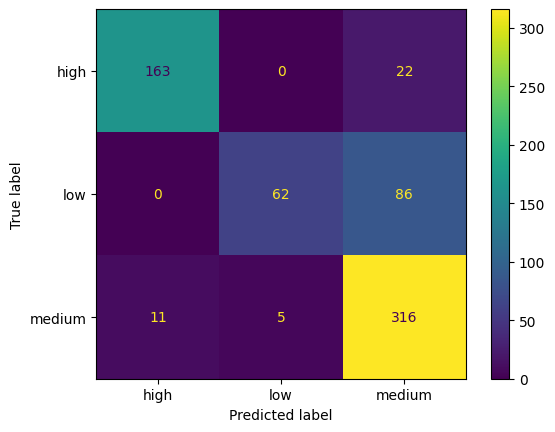

---
Class population: 
0
2    332
0    185
1    148
Name: count, dtype: int64
---
Global accuracy: 0.81
---
Classes: ['high' 'low' 'medium']
Precision: [0.93678161 0.92537313 0.74528302]
Recall: [0.88108108 0.41891892 0.95180723]
F1 score: [0.90807799 0.57674419 0.83597884]


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Extract data
X = data_bat[['I', 'V', 'T']].copy()
y = data_bat['label'].copy()

# Encode our labels as 0, 1, 2 instead of text
enc = LabelEncoder()
y = enc.fit_transform(y)

# Data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

# Declare the model
rfc = RandomForestClassifier(n_estimators=5, criterion='gini', max_depth=3, random_state=0) # OvR training
rfc.fit(X_train, y_train)

# Run predictions
y_preds = rfc.predict(X_test)

# Plot confusion matrix
cm = confusion_matrix(y_pred=y_preds, y_true=y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=enc.classes_)
disp.plot()
plt.show()

# # Model details
# print(f'Logistic regression features: {logr.n_features_in_}')
# print(f'Logistic regression iterations: {logr.n_iter_}')

# Display results
df_y = pd.DataFrame(data=y_test)
print(f'---\nClass population: \n{df_y.value_counts()}')
print(f'---\nGlobal accuracy: {accuracy_score(y_test, y_preds):.2f}')
print(f'---\nClasses: {enc.classes_}')
print(f'Precision: {precision_score(y_test, y_preds, average=None)}')
print(f'Recall: {recall_score(y_test, y_preds, average=None)}')
print(f'F1 score: {f1_score(y_test, y_preds, average=None)}')

Una cosa interessante di *Alberi Decisionali* e *Random Forest* è che sono immuni ai dati non scalati.

**Grazie per l'attenzione!**